# Classifying satellite images to monitor Earth’s surface
### By Arian Bahram, Arianna Gonzalez, & Naina Talasu

In [1]:
import kagglehub
import pandas as pd
import os


# Download latest version
path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")

print("Path to dataset files:", path)

data_dir = os.path.join(path, "data")
rows = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    
    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)
            rows.append([img_path, label])

df = pd.DataFrame(rows, columns=["image_path", "label"])
df.to_csv("satellite_dataset.csv", index=False)

print(df.head())

Path to dataset files: C:\Users\arici\.cache\kagglehub\datasets\mahmoudreda55\satellite-image-classification\versions\1
                                          image_path   label
0  C:\Users\arici\.cache\kagglehub\datasets\mahmo...  cloudy
1  C:\Users\arici\.cache\kagglehub\datasets\mahmo...  cloudy
2  C:\Users\arici\.cache\kagglehub\datasets\mahmo...  cloudy
3  C:\Users\arici\.cache\kagglehub\datasets\mahmo...  cloudy
4  C:\Users\arici\.cache\kagglehub\datasets\mahmo...  cloudy


## Dataset Exploration

In [2]:
images = df.groupby("label")["image_path"].apply(list).to_dict()
image_count = df['label'].value_counts().to_dict()
print(image_count)
total_images = len(df)
print(f"Total images: {total_images}")

{'cloudy': 1500, 'green_area': 1500, 'water': 1500, 'desert': 1131}
Total images: 5631


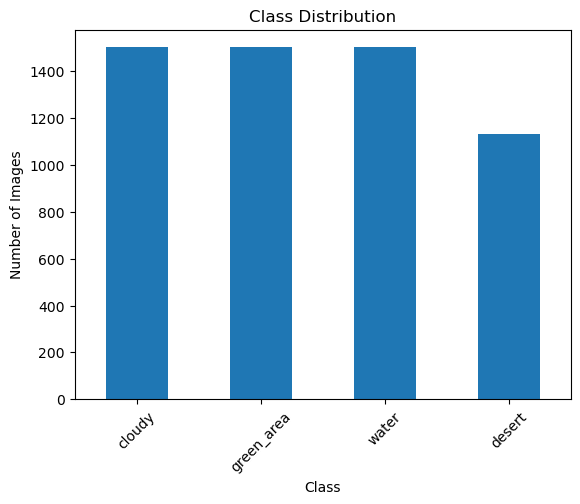

In [3]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts()

plt.figure()
counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

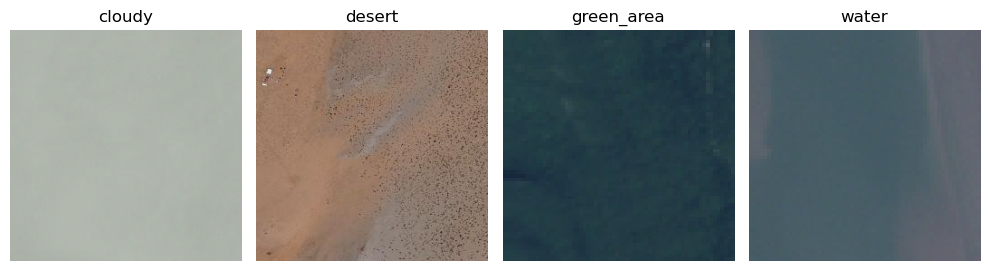

In [4]:
from PIL import Image
plt.figure(figsize=(10, 6))

for i, label in enumerate(df['label'].unique()):
    sample = df[df['label'] == label].sample(1).iloc[0]
    img = Image.open(sample['image_path'])
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
sizes = []

for path in df['image_path'][:200]:  # sample for speed
    img = Image.open(path)
    sizes.append(img.size)

print(set(sizes))

{(256, 256)}


In [6]:
import numpy as np

img = Image.open(df.iloc[0]['image_path'])
img_array = np.array(img)

print("Shape:", img_array.shape)
print("Min pixel:", img_array.min())
print("Max pixel:", img_array.max())

Shape: (256, 256, 4)
Min pixel: 0
Max pixel: 148


## Data Preprocessing

In [7]:
import cv2

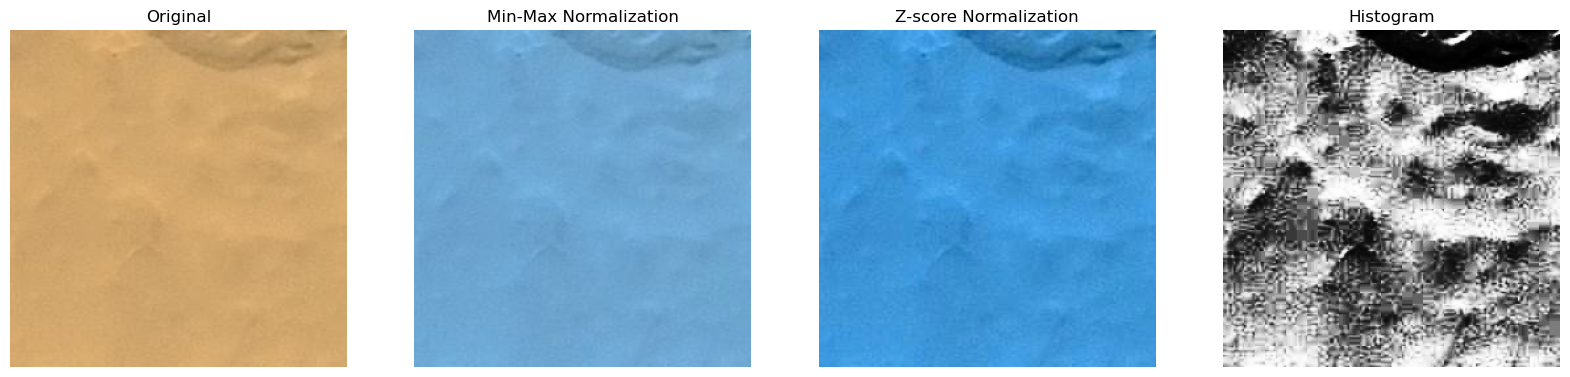

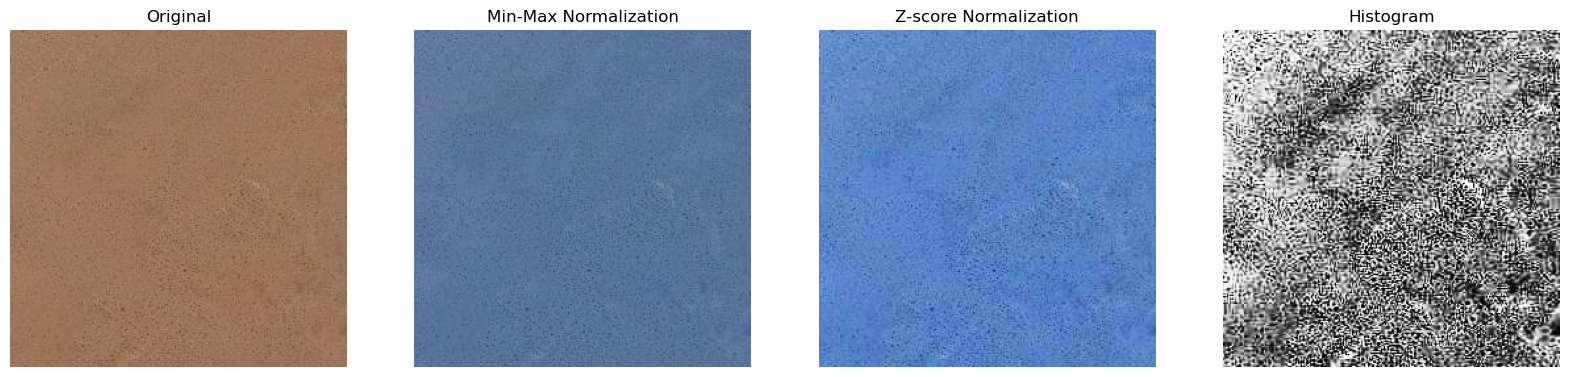

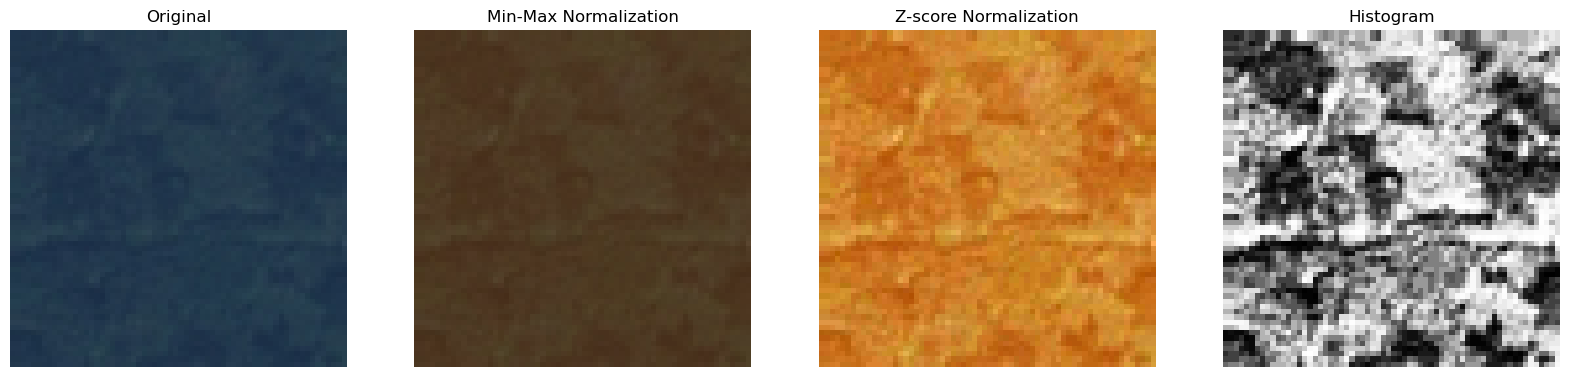

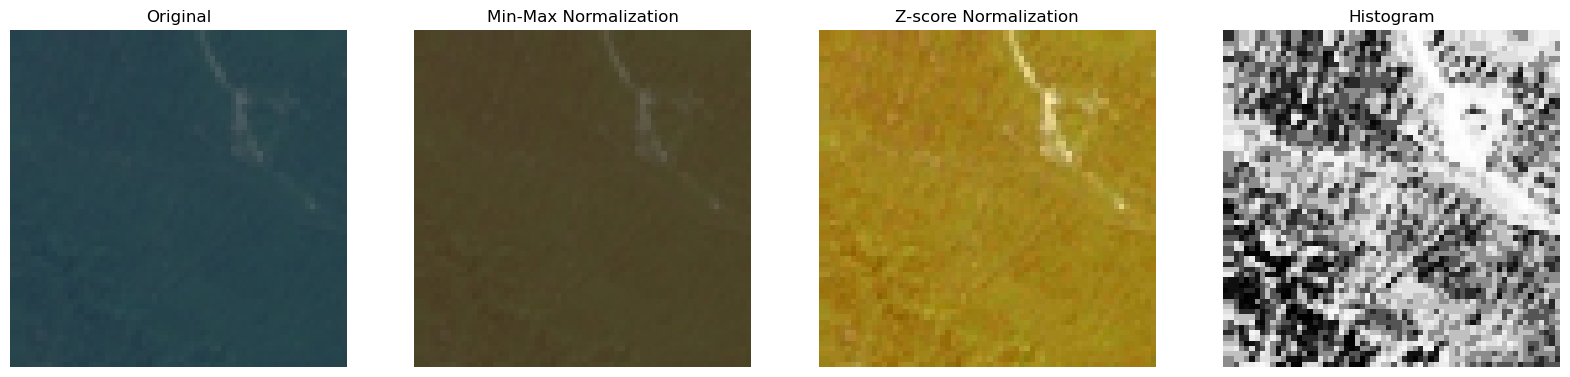

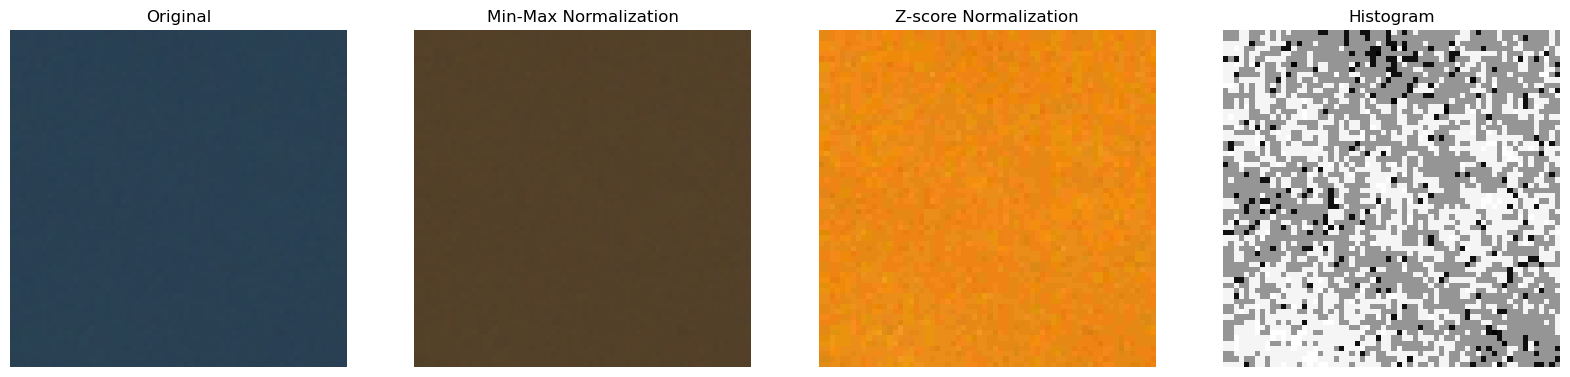

In [8]:
def normalize_image(image):
    # Min-max 
    min_max = image / 255.0

    # Z-score 
    z_score = (image - np.mean(image)) / (np.std(image) + 1e-8)

    # Histogram 
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist_eq = cv2.equalizeHist(gray)

    return min_max, z_score, hist_eq


sample_paths = set(df['image_path'].sample(5, random_state=42))

for path in df['image_path']:
    image = cv2.imread(path)
    if image is None:
        print(f"Failed: {path}")
        continue

    min_max, z_score, hist_eq = normalize_image(image)

    if path in sample_paths:
        plt.figure(figsize=(20, 5))

        plt.subplot(141)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title('Original')
        plt.axis('off')

        plt.subplot(142)
        plt.imshow(min_max)
        plt.title('Min-Max Normalization')
        plt.axis('off')

        plt.subplot(143)
        plt.imshow((z_score - z_score.min()) / (z_score.max() - z_score.min()))
        plt.title('Z-score Normalization')
        plt.axis('off')

        plt.subplot(144)
        plt.imshow(hist_eq, cmap='gray')
        plt.title('Histogram')
        plt.axis('off')

        plt.show()


## Train/Validation/Test Split

In [9]:
from sklearn.model_selection import train_test_split

# map labels to int representations
label_to_idx = {'cloudy': 0, 'desert': 1, 'green_area': 2, 'water': 3}

df['label_idx'] = df['label'].map(label_to_idx)

# stratified split: 70% train, 15% validation, 15% test
# get 70% training split 
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label_idx'],
    random_state=42
)

# split remaining 30% for validation and test splits
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label_idx'],
    random_state=42
)

# reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# verify splits
print("Train set size:", len(train_df))
print("Validation set size:", len(val_df))
print("Test set size:", len(test_df))

print("\nTrain class distribution:")
print(train_df['label'].value_counts())

print("\nValidation class distribution:")
print(val_df['label'].value_counts())

print("\nTest class distribution:")
print(test_df['label'].value_counts())


Train set size: 3941
Validation set size: 845
Test set size: 845

Train class distribution:
label
green_area    1050
cloudy        1050
water         1050
desert         791
Name: count, dtype: int64

Validation class distribution:
label
cloudy        225
green_area    225
water         225
desert        170
Name: count, dtype: int64

Test class distribution:
label
green_area    225
water         225
cloudy        225
desert        170
Name: count, dtype: int64


## Data Preprocessing and Setup

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# resize images to 244x244
IMG_SIZE = 224
# 32 images processed at once during training
# compromise between speed and memory
BATCH_SIZE = 32

# defines how training images are processed before entering the model
# random flips and small rotations help prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# defines how validation and test images are processed before entering the model
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# custom Dataset class for PyTorch 
class SatelliteDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # get image path and label
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label_idx']
        
        # open image and confirm its in color
        image = Image.open(img_path).convert('RGB')

        # applies image transformations
        if self.transform:
            image = self.transform(image)

        return image, label

# create dataset objects so PyTorch understands the dataset and applies transforms
train_dataset = SatelliteDataset(train_df, transform=train_transform)
val_dataset = SatelliteDataset(val_df, transform=val_test_transform)
test_dataset = SatelliteDataset(test_df, transform=val_test_transform)

# DataLoaders to load data into the model
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created successfully.")

DataLoaders created successfully.


## Custom CNN Model

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 28 * 28, 256)  # depends on image size (224 → 28 after pooling)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    # defines how data flows through the network
    def forward(self, x):
        # Conv Block 1
        x = self.pool(F.relu(self.conv1(x)))   # (32, 112, 112)

        # Conv Block 2
        x = self.pool(F.relu(self.conv2(x)))   # (64, 56, 56)

        # Conv Block 3
        x = self.pool(F.relu(self.conv3(x)))   # (128, 28, 28)

        # Flatten to vector
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        # prediction before softmax
        return x

## Initialize CNN model

In [12]:
# checks for available GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# initialize the custom CNN model
model = CustomCNN(num_classes=4).to(device)

# applies softmax internally
criterion = nn.CrossEntropyLoss()
# controls how the model updates its weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model initialized on:", device)

Model initialized on: cpu


## Define Training Function

In [13]:
from sklearn.metrics import accuracy_score

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    # save metrics
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        # training phase
        model.train()
        running_train_loss = 0.0
        train_preds = []
        train_labels = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()          # clear old gradients
            outputs = model(images)        # forward pass
            loss = criterion(outputs, labels)  # compute loss
            loss.backward()                # backpropagation
            optimizer.step()               # update weights

            # accumulate training loss
            running_train_loss += loss.item() * images.size(0)

            # get predicted class
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        # compute epoch training metrics
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        epoch_train_acc = accuracy_score(train_labels, train_preds)

        # save epoch training metrics
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        # Validation phase
        model.eval()
        running_val_loss = 0.0
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                # forward pass on validation data
                outputs = model(images)
                loss = criterion(outputs, labels)

                # accumulate validation loss
                running_val_loss += loss.item() * images.size(0)

                # get validation predictions
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        # compute epoch validation metrics
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = accuracy_score(val_labels, val_preds)

        # store epoch validation metrics
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        # print progress each epoch
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # return all saved metrics
    return train_losses, val_losses, train_accuracies, val_accuracies

## Train CNN model

In [14]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10
)

Epoch [1/10] Train Loss: 0.4793, Train Acc: 0.7729 | Val Loss: 0.3108, Val Acc: 0.8592
Epoch [2/10] Train Loss: 0.3137, Train Acc: 0.8683 | Val Loss: 0.4574, Val Acc: 0.8272
Epoch [3/10] Train Loss: 0.3269, Train Acc: 0.8561 | Val Loss: 0.3069, Val Acc: 0.8876
Epoch [4/10] Train Loss: 0.2474, Train Acc: 0.9114 | Val Loss: 0.3283, Val Acc: 0.8982
Epoch [5/10] Train Loss: 0.2928, Train Acc: 0.8909 | Val Loss: 0.2314, Val Acc: 0.9089
Epoch [6/10] Train Loss: 0.2753, Train Acc: 0.8914 | Val Loss: 0.2718, Val Acc: 0.8982
Epoch [7/10] Train Loss: 0.2319, Train Acc: 0.9132 | Val Loss: 0.2595, Val Acc: 0.9030
Epoch [8/10] Train Loss: 0.2232, Train Acc: 0.9127 | Val Loss: 0.2248, Val Acc: 0.9160
Epoch [9/10] Train Loss: 0.2264, Train Acc: 0.9145 | Val Loss: 0.2940, Val Acc: 0.8651
Epoch [10/10] Train Loss: 0.1997, Train Acc: 0.9175 | Val Loss: 0.2009, Val Acc: 0.9207


## Define Model Evaluation Function

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # compute evaluation metrics
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    # print results
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall:    {recall:.4f}")
    print(f"Test F1-Score:  {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # create confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return acc, precision, recall, f1, cm

## Evaluate CNN model

Test Accuracy:  0.9065
Test Precision: 0.9154
Test Recall:    0.9101
Test F1-Score:  0.9090

Classification Report:
              precision    recall  f1-score   support

      cloudy       0.96      0.94      0.95       225
      desert       0.95      0.96      0.96       170
  green_area       0.81      0.96      0.88       225
       water       0.94      0.77      0.85       225

    accuracy                           0.91       845
   macro avg       0.92      0.91      0.91       845
weighted avg       0.91      0.91      0.91       845



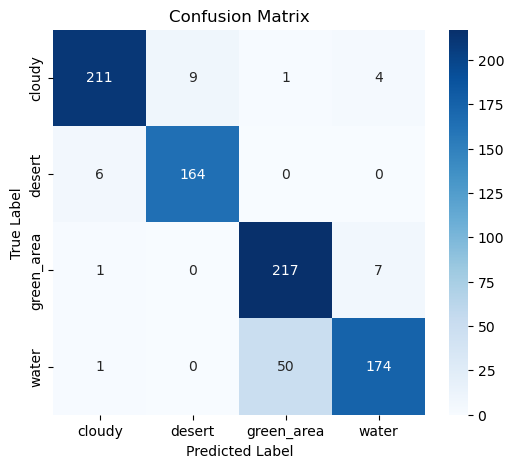

In [16]:
class_names = ['cloudy', 'desert', 'green_area', 'water']

cnn_acc, cnn_precision, cnn_recall, cnn_f1, cnn_cm = evaluate_model(
    model,
    test_loader,
    device,
    class_names
)

## Plot CNN Training and Validation Loss and Accuracy

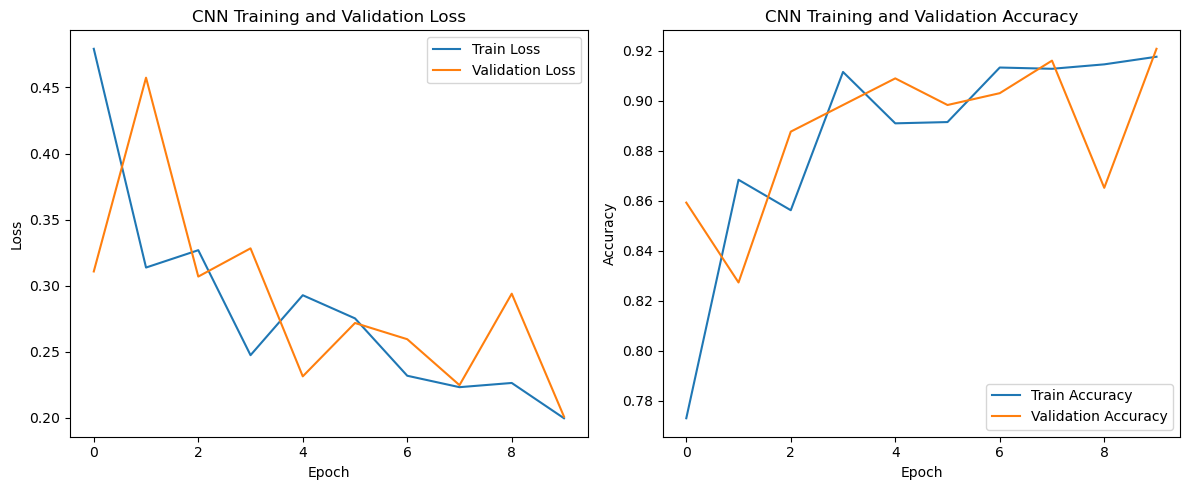

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Visualize CNN Predictions

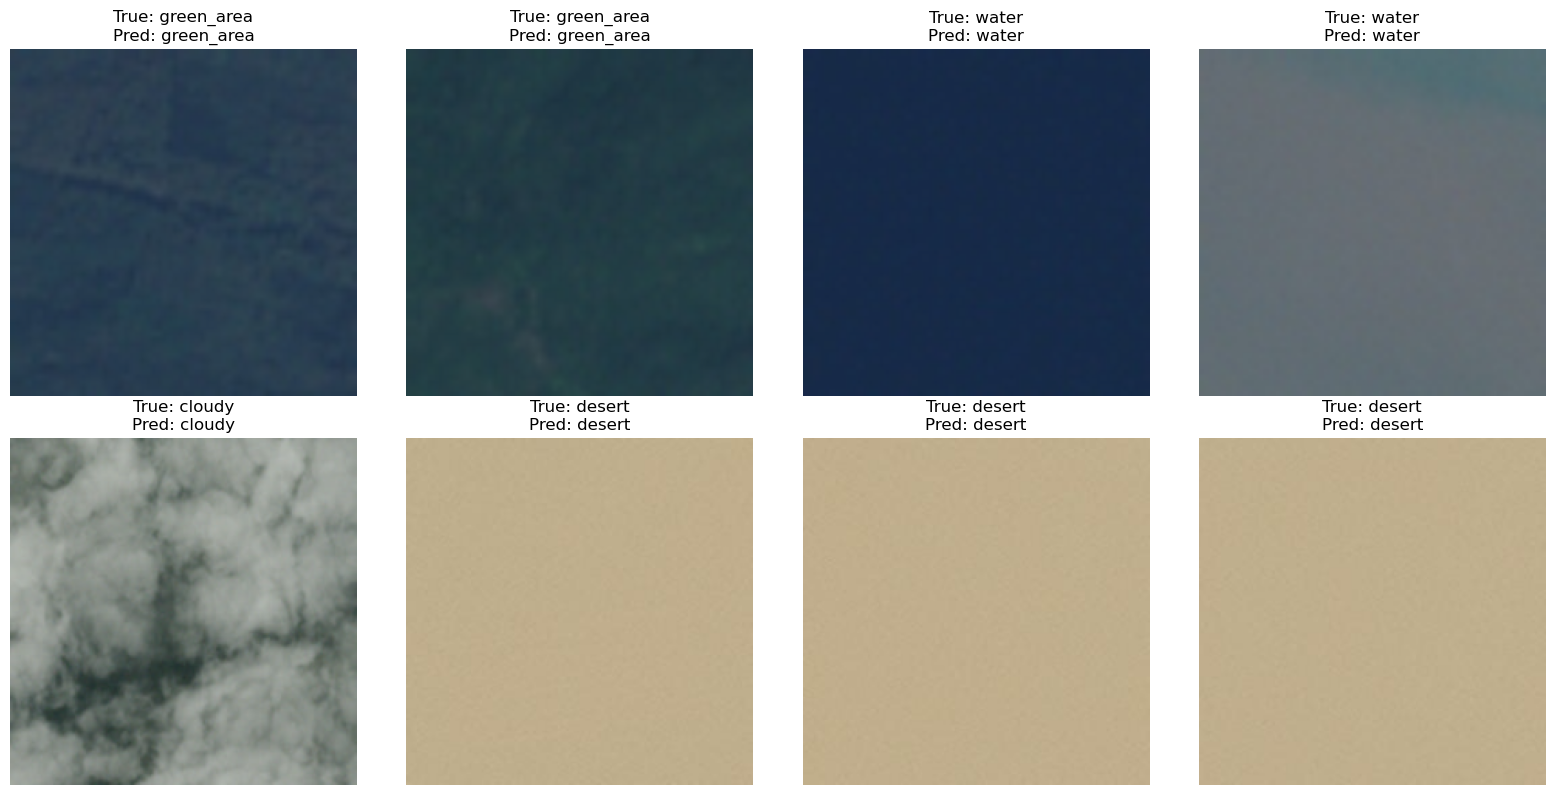

In [19]:
import numpy as np

def show_predictions(model, data_loader, device, class_names, num_images=8):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(16, 8))

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    plt.tight_layout()
                    plt.show()
                    return

                img = images[i].cpu().permute(1, 2, 0).numpy()
                img = (img * 0.5) + 0.5
                img = np.clip(img, 0, 1)

                plt.subplot(2, 4, images_shown + 1)
                plt.imshow(img)
                plt.title(f"True: {class_names[labels[i].item()]}\nPred: {class_names[preds[i].item()]}")
                plt.axis("off")

                images_shown += 1

    plt.tight_layout()
    plt.show()

show_predictions(model, test_loader, device, class_names)

## ResNet50

In [20]:
from torchvision import models
import torch.nn as nn

# load ResNet50 model
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# freeze all layers to preserve ResNet's pretrained weights
for param in resnet_model.parameters():
    param.requires_grad = False

# adjust resnet for 4 output classes
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 4)

resnet_model = resnet_model.to(device)

# loss function
criterion_resnet = nn.CrossEntropyLoss()
# optimizer only updates the final layer
optimizer_resnet = torch.optim.Adam(resnet_model.fc.parameters(), lr=0.001)

print("ResNet50 initialized.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\arici/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:03<00:00, 25.8MB/s]


ResNet50 initialized.


## Train ResNet50

In [21]:
resnet_train_losses, resnet_val_losses, resnet_train_accuracies, resnet_val_accuracies = train_model(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_resnet,
    optimizer=optimizer_resnet,
    device=device,
    epochs=10
)

Epoch [1/10] Train Loss: 0.3814, Train Acc: 0.9221 | Val Loss: 0.2160, Val Acc: 0.9550
Epoch [2/10] Train Loss: 0.1106, Train Acc: 0.9774 | Val Loss: 0.1219, Val Acc: 0.9870
Epoch [3/10] Train Loss: 0.0780, Train Acc: 0.9810 | Val Loss: 0.0827, Val Acc: 0.9893
Epoch [4/10] Train Loss: 0.0631, Train Acc: 0.9860 | Val Loss: 0.0658, Val Acc: 0.9905
Epoch [5/10] Train Loss: 0.0558, Train Acc: 0.9860 | Val Loss: 0.0519, Val Acc: 0.9953
Epoch [6/10] Train Loss: 0.0460, Train Acc: 0.9901 | Val Loss: 0.0538, Val Acc: 0.9917
Epoch [7/10] Train Loss: 0.0450, Train Acc: 0.9878 | Val Loss: 0.0449, Val Acc: 0.9941
Epoch [8/10] Train Loss: 0.0369, Train Acc: 0.9904 | Val Loss: 0.0382, Val Acc: 0.9964
Epoch [9/10] Train Loss: 0.0423, Train Acc: 0.9899 | Val Loss: 0.0308, Val Acc: 0.9976
Epoch [10/10] Train Loss: 0.0291, Train Acc: 0.9924 | Val Loss: 0.0312, Val Acc: 0.9941


## Evaluate ResNet50

Test Accuracy:  0.9941
Test Precision: 0.9941
Test Recall:    0.9944
Test F1-Score:  0.9943

Classification Report:
              precision    recall  f1-score   support

      cloudy       1.00      0.99      1.00       225
      desert       0.99      1.00      1.00       170
  green_area       0.99      1.00      0.99       225
       water       0.99      0.99      0.99       225

    accuracy                           0.99       845
   macro avg       0.99      0.99      0.99       845
weighted avg       0.99      0.99      0.99       845



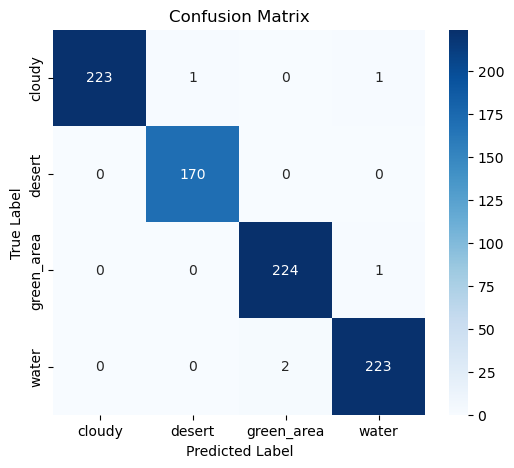

In [22]:
resnet_acc, resnet_precision, resnet_recall, resnet_f1, resnet_cm = evaluate_model(
    resnet_model,
    test_loader,
    device,
    class_names
)

## Plot ResNet50 Training and Validation Loss and Accuracy

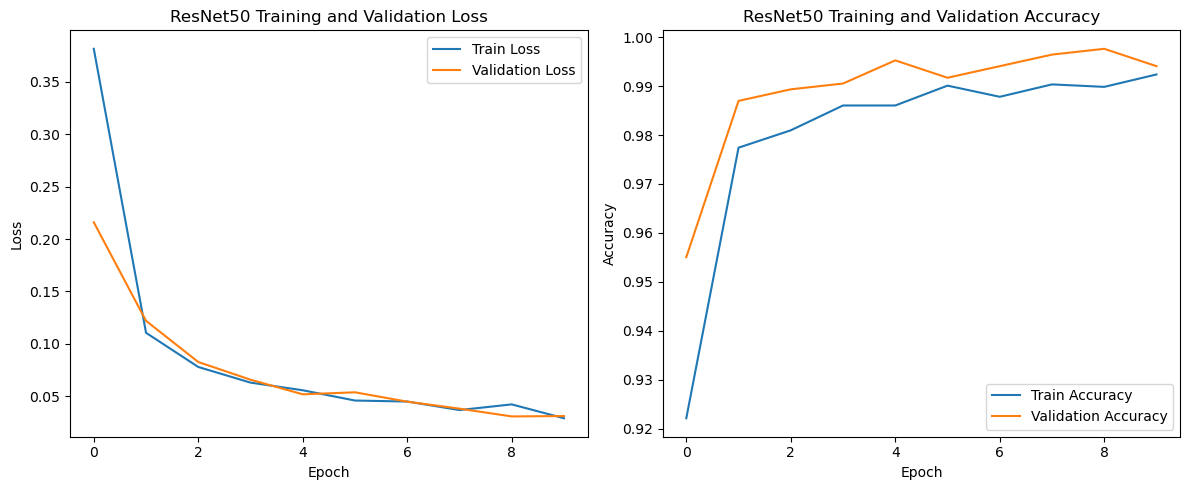

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(resnet_train_losses, label='Train Loss')
plt.plot(resnet_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet50 Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(resnet_train_accuracies, label='Train Accuracy')
plt.plot(resnet_val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet50 Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Visualize ResNet50 Predictions

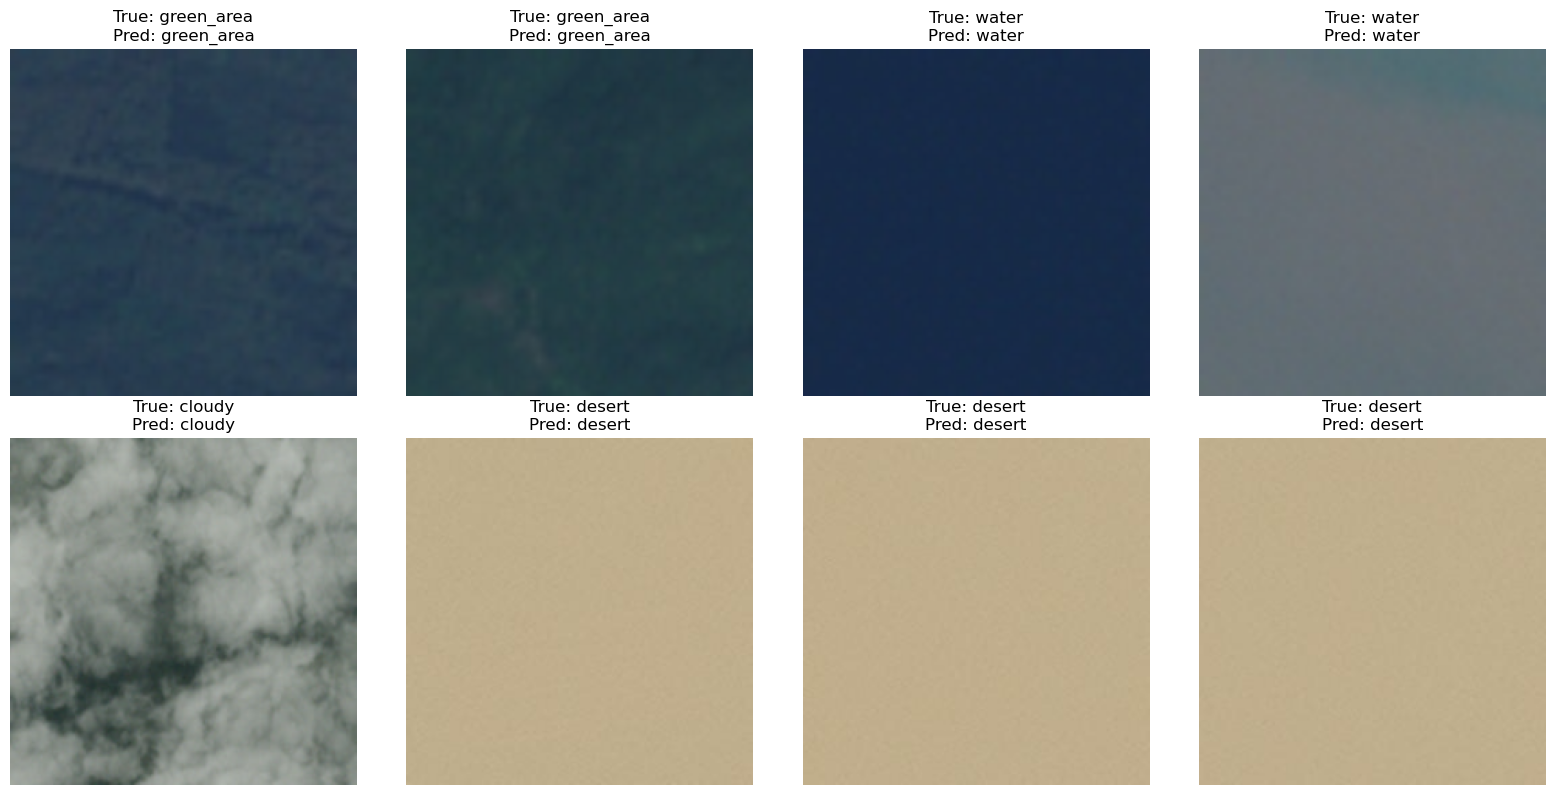

In [24]:
show_predictions(resnet_model, test_loader, device, class_names)

## Compare Evaluation Metrics for Custom CNN Model and ResNet50

In [25]:
import pandas as pd

results_df = pd.DataFrame({
    'Model': ['Custom CNN', 'ResNet50'],
    'Accuracy': [cnn_acc, resnet_acc],
    'Precision': [cnn_precision, resnet_precision],
    'Recall': [cnn_recall, resnet_recall],
    'F1-Score': [cnn_f1, resnet_f1]
})

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Custom CNN,0.906509,0.915422,0.910065,0.908956
1,ResNet50,0.994083,0.994103,0.994444,0.994266


## Visualize Model Perfornance Comparison

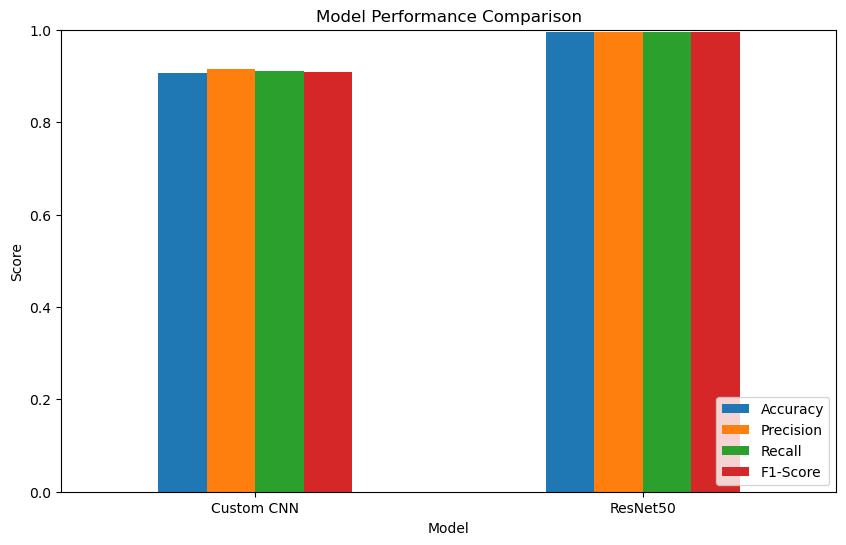

In [26]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()